<a href="https://colab.research.google.com/github/abarbierif/IA_UBB/blob/Project/SIFT_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `SIFT Fashion-MNIST`
En este notebook se extrae el vector de características de un subconjunto de datos de `Fashion-MNIST` usando `SIFT`. En un principio se consideran 10 clases (total de clases) y luego se consideran solo 2 clases para analizar el desempeño en un problema menos complejo. Todos los vectores de características obtenidos son clasificados con `MLP` y `RFC`.

### `Librerias`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd
import pickle
import time
from tensorflow.keras.preprocessing.image import smart_resize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import GlorotUniform, Zeros
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Accuracy, F1Score

os.chdir('/content/drive/MyDrive/AI/Project')
sys.path.append('/content/drive/MyDrive/AI/Project/py_utils')

from data_loading import *
from data_visualization import *
from utils import *
from data_preprocessing import *

#reproducibility (deterministic)
from tensorflow.keras.utils import set_random_seed
from tensorflow.config.experimental import enable_op_determinism

set_random_seed(1)
enable_op_determinism()

os.getcwd()

'/content/drive/MyDrive/AI/Project'

In [ ]:
os.listdir('./')

['results',
 'py_utils',
 'feature_vectors',
 'weights',
 'keypointsCIFAR10.pdf',
 'SIFT_CIFAR10.ipynb',
 'CNN_CIFAR10.ipynb',
 'CNN_FashionMNIST.ipynb',
 'SIFT_FashionMNIST.ipynb']

### `Cargar Dataset`

In [ ]:
X, y = load_data(
    source='tfds',
    to='ndarray',
    dataset='fashion_mnist',
    dims=(28,28)
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/60000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.IEQH52_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.IEQH52_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


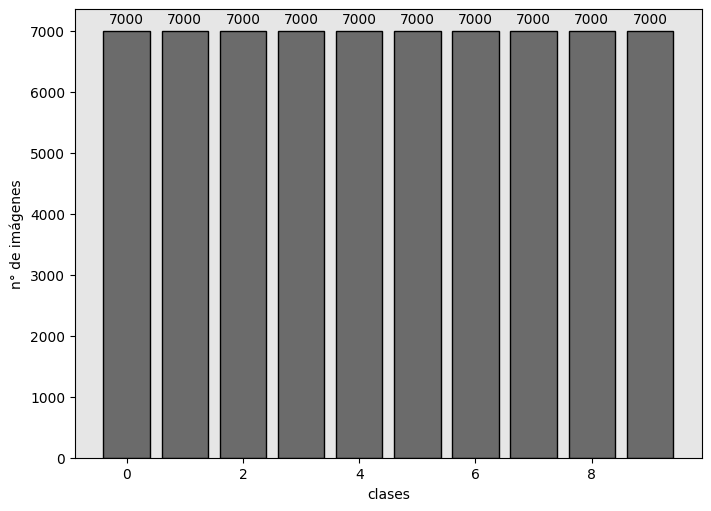

In [ ]:
classes_distribution(
    y,
    figsize=(7,5),
    title='',
    hatch='',
    cmap=None,
    xlabel='clases',
    ylabel='n° de imágenes',
    labelrotation=0,
    facecolor='#e6e6e6',
    color='#6b6b6b'
)

### `Funciones`

In [ ]:
def testing_data(X, Y, samples_per_class):

    '''
    Esta función selecciona un subconjunto balanceado de datos de un conjunto de datos mayor, asegurando que haya un número igual de muestras para cada clase.

    Los datos seleccionados se utilizan para fines de prueba o evaluación, y la función también imprime la forma de los datos resultantes y un gráfico de la distribución de clases.

    Parámetros:
        X: Conjunto de imágenes o datos (ndarray).
        Y: Etiquetas correspondientes a las imágenes o datos (ndarray).
        samples_per_class: Número de muestras a seleccionar por cada clase.

    Retorna:
        X: Subconjunto de datos seleccionados (ndarray).
        Y: Etiquetas correspondientes al subconjunto de datos (ndarray).
    '''

    if samples_per_class > np.max(np.unique(Y, return_counts=True)[1]):
        raise ValueError(f"samples_per_class must be less than {np.max(np.unique(Y, return_counts=True)[1])}")

    for _ in np.unique(Y):
        X = np.delete(X, np.argwhere(Y == _)[samples_per_class:], axis=0)
        Y = np.delete(Y, np.argwhere(Y == _)[samples_per_class:], axis=0)

    print(f"X shape: {X.shape}, Y shape: {Y.shape}")
    classes_distribution(Y, figsize=(7,5), title='', hatch='', cmap=None, xlabel='clases', ylabel='n° de imágenes', labelrotation=0, facecolor='#e6e6e6', color='#6b6b6b')

    return X, Y

In [ ]:
def train_predict(x=None, y=None, classifier=None, classes=None, weights_path=None, write_file=None):

    '''
    Esta función entrena un clasificador ('rfc' o 'mlp') utilizando validación cruzada estratificada con 5 folds
    y evalúa su rendimiento en términos de precisión (accuracy) y F1-score ponderado.

    Los resultados de cada fold y las medias se almacenan en un DataFrame y, opcionalmente, se guardan en un archivo.

    Parámetros:
        x: Vectores de características (ndarray).
        y: Etiquetas (ndarray).
        classifier: Tipo de clasificador a utilizar ('rfc' para RandomForestClassifier o 'mlp' para un perceptrón multicapa).
        classes: Número de clases (requerido para 'mlp').
        weights_path: Ruta para guardar los pesos del modelo 'mlp' (opcional).
        write_file: Ruta para guardar el DataFrame con los resultados (opcional).

    Retorna:
        None. (Los resultados se almacenan en un DataFrame y se guardan en un archivo si se especifica 'write_file'.)

    '''

    if classifier not in ['rfc', 'mlp']:
        raise ValueError("classifier must be 'rfc' or 'mlp'")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    df = pd.DataFrame(columns=['','accuracy', 'f1_weighted'])

    for n, (train_idx, test_idx) in enumerate(skf.split(x, y)):

        if classifier == 'rfc':
            clf = RandomForestClassifier(n_estimators=500, random_state=1)
            clf.fit(x[train_idx], y[train_idx])

            y_pred = clf.predict(x[test_idx])
            accuracy = accuracy_score(y[test_idx], y_pred)
            f1 = f1_score(y[test_idx], y_pred, average='weighted')

            df.loc[len(df)] = ['',accuracy, f1]

        elif classifier == 'mlp':

            dimdin = x.shape[1]

            clf = Sequential()
            clf.add(Dense(256, input_dim=dimdin, activation='relu', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))
            clf.add(BatchNormalization())
            clf.add(Dropout(0.5, seed=1))
            clf.add(Dense(classes, activation='softmax', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))

            optimizer_adam = Adam(learning_rate=0.001)
            SC = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
            MCP = ModelCheckpoint(filepath=weights_path+f"_iteration{n}.keras", save_best_only=True, verbose=0)

            clf.compile(
                optimizer=optimizer_adam,
                loss='categorical_crossentropy',
                metrics=['accuracy', F1Score(average='weighted')]
            )

            fit_hist = clf.fit(
                x=x[train_idx],
                y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[train_idx]),
                epochs=50,
                batch_size=32,
                validation_split=0.2,
                verbose=1,
                callbacks=[SC,MCP],
                shuffle=True
            )

            score = clf.evaluate(x=x[test_idx], y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[test_idx]), verbose=1)

            df.loc[len(df)] = ['', score[1], score[2]]


        del clf

    df.loc[len(df)] = ['means', df['accuracy'].mean(), df['f1_weighted'].mean()]

    #write dataframe
    if write_file != None:
        with open(write_file, 'wb') as file:
            pickle.dump(df, file)

In [ ]:
def sift_feature_extractor(X, n_clusters=100, feature_vectors_path=None):

    '''
    Esta función extrae características SIFT de un conjunto de imágenes y las utiliza para crear un vocabulario de palabras visuales
    mediante la agrupación en clusters utilizando el algoritmo KMeans.

    Cada imagen se representa como un vector de características (histograma) que indica la frecuencia de cada palabra visual
    (cluster) en la imagen.

    Parámetros:
        X: Conjunto de imágenes (ndarray).
        n_clusters: Número de clusters a utilizar en KMeans, que define el tamaño del vocabulario de palabras visuales (por defecto, 100).
        feature_vectors_path: Ruta para guardar los vectores de características extraídos (opcional).

    Retorna:
        sift_feature_vectors: Un ndarray que contiene los vectores de características SIFT para cada imagen en X.
    '''

    extractor = cv2.xfeatures2d.SIFT_create()

    descriptors = []
    for img in X:
        kp, des = extractor.detectAndCompute(img, None)
        if des is not None:
            descriptors.append(des)

    descriptors_stack = np.vstack(descriptors)
    print(f"descriptors_stack shape: {descriptors_stack.shape}")

    kmeans = KMeans(n_clusters=n_clusters, random_state=1)
    kmeans.fit(descriptors_stack)

    sift_feature_vectors = []
    for img in X:
        kp, des = extractor.detectAndCompute(img, None)
        if des is not None:
            words = kmeans.predict(des)
            # Create a histogram of cluster frequencies
            histogram = np.bincount(words, minlength=n_clusters)

            # Normalize the histogram
            feature_vector = histogram / np.sum(histogram)
        else:
            feature_vector = np.zeros(n_clusters)
        sift_feature_vectors.append(feature_vector)

    sift_feature_vectors = np.array(sift_feature_vectors)
    np.save(feature_vectors_path, sift_feature_vectors)
    print(f"sift_feature_vectors shape: {sift_feature_vectors.shape}")

    return sift_feature_vectors

### `Preprocesamiento`

X shape: (5000, 28, 28, 1), Y shape: (5000,)


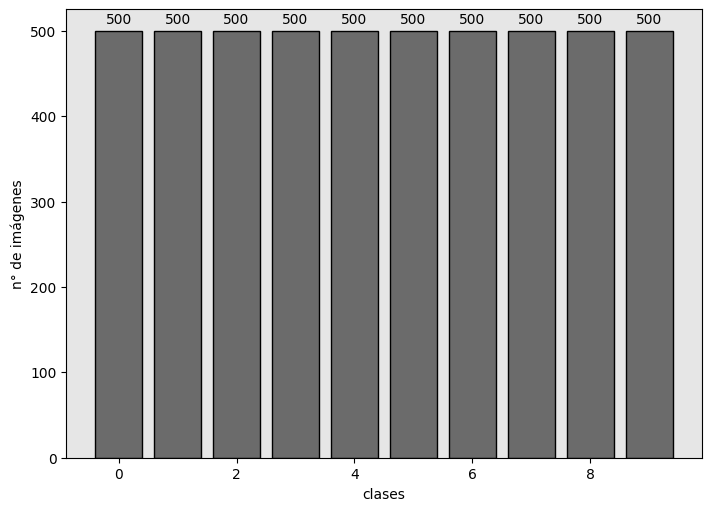

In [ ]:
#selección de un subconjunto de los datos
X_reduced_10classes, y_reduced_10classes = testing_data(X, y, samples_per_class=500)

In [ ]:
#redimensionamiento de las imágenes (28, 28) -> (224, 224)
X_reduced_10classes = np.array([smart_resize(img, (224, 224)) for img in X_reduced_10classes])

print(f"X shape: {X_reduced_10classes.shape}, Y shape: {y_reduced_10classes.shape}")

X shape: (5000, 224, 224, 1), Y shape: (5000,)


In [ ]:
#selección de solo 2 clases
X_reduced_2classes = X_reduced_10classes[np.isin(y_reduced_10classes, [0, 1])]
y_reduced_2classes = y_reduced_10classes[np.isin(y_reduced_10classes, [0, 1])]

print(f"X shape: {X_reduced_2classes.shape}, Y shape: {y_reduced_2classes.shape}")

X shape: (1000, 224, 224, 1), Y shape: (1000,)


## `SIFT feature extractor`

### `Dibujando Keypoints`

In [ ]:
sift = cv2.xfeatures2d.SIFT_create()
kp, des = sift.detectAndCompute(X_reduced_10classes[0], None)
print(f"kp shape: {len(kp)}, des shape: {des.shape}")

kp shape: 15, des shape: (15, 128)


(-0.5, 223.5, 223.5, -0.5)

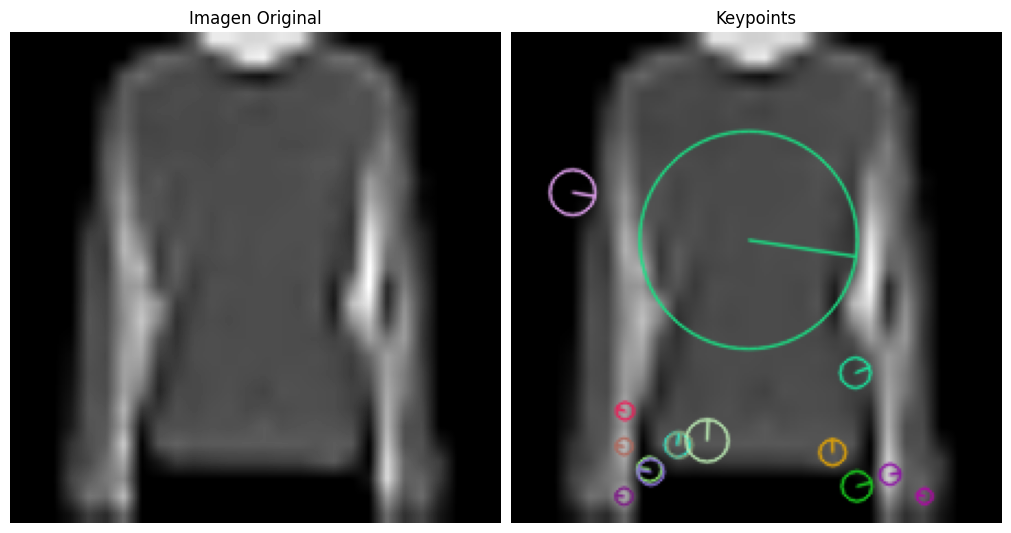

In [ ]:
img_kp = cv2.drawKeypoints(X_reduced_10classes[0], kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axs = plt.subplots(1,2,layout='constrained',figsize=(10,10))
axs[0].imshow(X_reduced_10classes[0], cmap='gray')
axs[0].set_title('Imagen Original')
axs[0].axis('off')
axs[1].imshow(img_kp)
axs[1].set_title('Keypoints')
axs[1].axis('off')

### `Vectores de Caracerísticas SIFT`

#### `10 clases`

In [ ]:
start_time = time.time()
sift_feature_vectors_10classes = sift_feature_extractor(
    X_reduced_10classes,
    n_clusters=100,
    feature_vectors_path='feature_vectors/sift_fashionMNIST_10classes.npy'
)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time} segundos")

descriptors_stack shape: (156144, 128)
sift_feature_vectors shape: (5000, 100)
Tiempo de ejecución: 185.04994106292725 segundos


#### `2 clases`

In [ ]:
start_time = time.time()
sift_feature_vectors_2classes = sift_feature_extractor(
    X_reduced_2classes,
    n_clusters=100,
    feature_vectors_path='feature_vectors/sift_fashionMNIST_2classes.npy'
)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time} segundos")

descriptors_stack shape: (21995, 128)
sift_feature_vectors shape: (1000, 100)
Tiempo de ejecución: 33.07053017616272 segundos


### `Clasificación`

#### `MLP 10 classes`

In [ ]:
train_predict(
    x=sift_feature_vectors_10classes,
    y=y_reduced_10classes,
    classifier='mlp',
    classes=10,
    weights_path='weights/SIFTFashionMNISTMLP_10Classes',
    write_file='results/SIFTFashionMNISTMLP_10Classes.pkl'
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.2769 - f1_score: 0.2680 - loss: 2.0773 - val_accuracy: 0.4000 - val_f1_score: 0.3877 - val_loss: 2.2017
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5523 - f1_score: 0.5396 - loss: 1.3742 - val_accuracy: 0.3725 - val_f1_score: 0.3630 - val_loss: 2.0771
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5981 - f1_score: 0.5902 - loss: 1.2297 - val_accuracy: 0.4712 - val_f1_score: 0.4786 - val_loss: 1.9088
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6106 - f1_score: 0.6051 - loss: 1.1547 - val_accuracy: 0.5462 - val_f1_score: 0.5552 - val_loss: 1.6745
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6488 - f1_score: 0.6443 - loss: 1.1171 - val_accuracy: 0.5962 - val_f1_score: 0.6028 - val_loss: 1.4327
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6479 - f1_score: 0.6443 - loss: 1.0739 - val_accuracy: 0.5987 - val_f1_score: 0.5995 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2626 - f1_score: 0.2580 - loss: 2.1124 - val_accuracy: 0.4400 - val_f1_score: 0.4336 - val_loss: 2.2069
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5354 - f1_score: 0.5171 - loss: 1.3824 - val_accuracy: 0.3462 - val_f1_score: 0.3315 - val_loss: 2.0808
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5864 - f1_score: 0.5800 - loss: 1.2378 - val_accuracy: 0.4613 - val_f1_score: 0.4682 - val_loss: 1.9144
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6043 - f1_score: 0.5996 - loss: 1.1675 - val_accuracy: 0.5512 - val_f1_score: 0.5635 - val_loss: 1.6917
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6128 - f1_score: 0.6092 - loss: 1.1399 - val_accuracy: 0.5913 - val_f1_score: 0.5962 - val_loss: 1.4390
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6315 - f1_score: 0.6274 - loss: 1.0793 - val_accuracy: 0.6025 - val_f1_score: 0.6049 - val_los

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2701 - f1_score: 0.2632 - loss: 2.0933 - val_accuracy: 0.4762 - val_f1_score: 0.4594 - val_loss: 2.2043
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5533 - f1_score: 0.5426 - loss: 1.3549 - val_accuracy: 0.4162 - val_f1_score: 0.4123 - val_loss: 2.0711
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5836 - f1_score: 0.5782 - loss: 1.1847 - val_accuracy: 0.4963 - val_f1_score: 0.5089 - val_loss: 1.9003
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6161 - f1_score: 0.6104 - loss: 1.1380 - val_accuracy: 0.5688 - val_f1_score: 0.5808 - val_loss: 1.6774
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6322 - f1_score: 0.6278 - loss: 1.0672 - val_accuracy: 0.5975 - val_f1_score: 0.6018 - val_loss: 1.4301
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6437 - f1_score: 0.6393 - loss: 1.0510 - val_accuracy: 0.5925 - val_f1_score: 0.5946 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2631 - f1_score: 0.2573 - loss: 2.0818 - val_accuracy: 0.4425 - val_f1_score: 0.4190 - val_loss: 2.2044
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5377 - f1_score: 0.5240 - loss: 1.3605 - val_accuracy: 0.3775 - val_f1_score: 0.3607 - val_loss: 2.0757
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5809 - f1_score: 0.5714 - loss: 1.2220 - val_accuracy: 0.4737 - val_f1_score: 0.4833 - val_loss: 1.9112
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6130 - f1_score: 0.6068 - loss: 1.1427 - val_accuracy: 0.5525 - val_f1_score: 0.5674 - val_loss: 1.6895
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6268 - f1_score: 0.6208 - loss: 1.0995 - val_accuracy: 0.5725 - val_f1_score: 0.5818 - val_loss: 1.4394
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6380 - f1_score: 0.6338 - loss: 1.0597 - val_accuracy: 0.5913 - val_f1_score: 0.5954 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2685 - f1_score: 0.2639 - loss: 2.1007 - val_accuracy: 0.3963 - val_f1_score: 0.4077 - val_loss: 2.2076
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5608 - f1_score: 0.5459 - loss: 1.3670 - val_accuracy: 0.3475 - val_f1_score: 0.3567 - val_loss: 2.0853
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5964 - f1_score: 0.5886 - loss: 1.2225 - val_accuracy: 0.4437 - val_f1_score: 0.4651 - val_loss: 1.9252
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6196 - f1_score: 0.6150 - loss: 1.1494 - val_accuracy: 0.5688 - val_f1_score: 0.5845 - val_loss: 1.7027
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6356 - f1_score: 0.6320 - loss: 1.0880 - val_accuracy: 0.5875 - val_f1_score: 0.5957 - val_loss: 1.4521
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6571 - f1_score: 0.6548 - loss: 1.0338 - val_accuracy: 0.6087 - val_f1_score: 0.6088 - val_loss

In [ ]:
with open('results/SIFTFashionMNISTMLP_10Classes.pkl', 'rb') as file:
    df_mlp_10classes = pickle.load(file)

df_mlp_10classes

,,accuracy,f1_weighted
0,,0.614,0.607110
1,,0.620,0.616486
2,,0.572,0.568172
3,,0.606,0.599223
4,,0.643,0.639702
5,means,0.611,0.606139


#### `MLP 2 clases`

In [ ]:
train_predict(
    x=sift_feature_vectors_2classes,
    y=y_reduced_2classes,
    classifier='mlp',
    classes=2,
    weights_path='weights/SIFTFashionMNISTMLP_2Classes',
    write_file='results/SIFTFashionMNISTMLP_2Classes.pkl'
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7153 - f1_score: 0.7152 - loss: 0.5277 - val_accuracy: 0.9062 - val_f1_score: 0.9062 - val_loss: 0.6438
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9433 - f1_score: 0.9433 - loss: 0.1658 - val_accuracy: 0.9187 - val_f1_score: 0.9184 - val_loss: 0.6150
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9522 - f1_score: 0.9523 - loss: 0.1337 - val_accuracy: 0.9312 - val_f1_score: 0.9312 - val_loss: 0.5937
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9727 - f1_score: 0.9727 - loss: 0.0863 - val_accuracy: 0.9125 - val_f1_score: 0.9120 - val_loss: 0.5738
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9663 - f1_score: 0.9663 - loss: 0.0852 - val_accuracy: 0.9062 - val_f1_score: 0.9056 - val_loss: 0.5552
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9930 - f1_score: 0.9930 - loss: 0.0535 - val_accuracy: 0.9312 - val_f1_score: 0.9310 - val_loss: 0.5321
Ep

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7255 - f1_score: 0.7251 - loss: 0.5475 - val_accuracy: 0.9062 - val_f1_score: 0.9059 - val_loss: 0.6442
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9381 - f1_score: 0.9381 - loss: 0.1973 - val_accuracy: 0.8875 - val_f1_score: 0.8862 - val_loss: 0.6173
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9499 - f1_score: 0.9499 - loss: 0.1376 - val_accuracy: 0.8750 - val_f1_score: 0.8732 - val_loss: 0.6009
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9454 - f1_score: 0.9455 - loss: 0.1359 - val_accuracy: 0.8500 - val_f1_score: 0.8468 - val_loss: 0.5865
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9701 - f1_score: 0.9701 - loss: 0.1125 - val_accuracy: 0.8500 - val_f1_score: 0.8468 - val_loss: 0.5722
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - f1_score: 0.9670 - loss: 0.0902 - val_accuracy: 0.8625 - val_f1_score: 0.8601 - val_loss: 0.5549
Ep

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7449 - f1_score: 0.7441 - loss: 0.5106 - val_accuracy: 0.9000 - val_f1_score: 0.9001 - val_loss: 0.6432
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9366 - f1_score: 0.9366 - loss: 0.1727 - val_accuracy: 0.8938 - val_f1_score: 0.8935 - val_loss: 0.6158
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9642 - f1_score: 0.9642 - loss: 0.1062 - val_accuracy: 0.8750 - val_f1_score: 0.8744 - val_loss: 0.5977
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9772 - f1_score: 0.9772 - loss: 0.0886 - val_accuracy: 0.8750 - val_f1_score: 0.8744 - val_loss: 0.5794
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9834 - f1_score: 0.9834 - loss: 0.0731 - val_accuracy: 0.8562 - val_f1_score: 0.8547 - val_loss: 0.5612
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9775 - f1_score: 0.9775 - loss: 0.0638 - val_accuracy: 0.8625 - val_f1_score: 0.8608 - val_loss: 0.5430
Ep

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7001 - f1_score: 0.6990 - loss: 0.5657 - val_accuracy: 0.8875 - val_f1_score: 0.8868 - val_loss: 0.6476
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9246 - f1_score: 0.9247 - loss: 0.2010 - val_accuracy: 0.8813 - val_f1_score: 0.8804 - val_loss: 0.6177
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9379 - f1_score: 0.9380 - loss: 0.1297 - val_accuracy: 0.8750 - val_f1_score: 0.8739 - val_loss: 0.5974
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9436 - f1_score: 0.9436 - loss: 0.1094 - val_accuracy: 0.8687 - val_f1_score: 0.8675 - val_loss: 0.5797
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9618 - f1_score: 0.9618 - loss: 0.0992 - val_accuracy: 0.9062 - val_f1_score: 0.9059 - val_loss: 0.5585
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9674 - f1_score: 0.9675 - loss: 0.0829 - val_accuracy: 0.9125 - val_f1_score: 0.9124 - val_loss: 0.5372
Ep

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7206 - f1_score: 0.7188 - loss: 0.5278 - val_accuracy: 0.9000 - val_f1_score: 0.9001 - val_loss: 0.6446
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9354 - f1_score: 0.9354 - loss: 0.1676 - val_accuracy: 0.8938 - val_f1_score: 0.8934 - val_loss: 0.6138
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9681 - f1_score: 0.9681 - loss: 0.1198 - val_accuracy: 0.9000 - val_f1_score: 0.8991 - val_loss: 0.5941
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9710 - f1_score: 0.9710 - loss: 0.0883 - val_accuracy: 0.8875 - val_f1_score: 0.8862 - val_loss: 0.5773
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9801 - f1_score: 0.9801 - loss: 0.0763 - val_accuracy: 0.8938 - val_f1_score: 0.8927 - val_loss: 0.5586
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9767 - f1_score: 0.9767 - loss: 0.0752 - val_accuracy: 0.8938 - val_f1_score: 0.8930 - val_loss: 0.5393


In [ ]:
with open('results/SIFTFashionMNISTMLP_2Classes.pkl', 'rb') as file:
    df_mlp_2classes = pickle.load(file)

df_mlp_2classes

,,accuracy,f1_weighted
0,,0.940,0.939976
1,,0.960,0.959964
2,,0.935,0.934985
3,,0.945,0.944988
4,,0.955,0.954990
5,means,0.947,0.946980


#### `RFC 10 clases`

In [ ]:
train_predict(
    x=sift_feature_vectors_10classes,
    y=y_reduced_10classes,
    classifier='rfc',
    classes=None,
    weights_path=None,
    write_file='results/SIFTFashionMNISTRFC_10Classes.pkl'
)

In [ ]:
with open('results/SIFTFashionMNISTRFC_10Classes.pkl', 'rb') as file:
    df_rfc_10classes = pickle.load(file)

df_rfc_10classes

,,accuracy,f1_weighted
0,,0.6140,0.598189
1,,0.6210,0.609532
2,,0.6030,0.593018
3,,0.6210,0.609141
4,,0.6320,0.620800
5,means,0.6182,0.606136


#### `RFC 2 clases`

In [ ]:
train_predict(
    x=sift_feature_vectors_2classes,
    y=y_reduced_2classes,
    classifier='rfc',
    classes=None,
    weights_path=None,
    write_file='results/SIFTFashionMNISTRFC_2Classes.pkl'
)

In [ ]:
with open('results/SIFTFashionMNISTRFC_2Classes.pkl', 'rb') as file:
    df_rfc_2classes = pickle.load(file)

df_rfc_2classes

,,accuracy,f1_weighted
0,,0.945,0.944999
1,,0.960,0.959984
2,,0.925,0.924998
3,,0.950,0.949995
4,,0.970,0.969997
5,means,0.950,0.949995
